In [1]:
import numpy as np
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.stats import multivariate_normal
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from torchvision.models.feature_extraction import create_feature_extractor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import models
import inference
import utils

In [2]:
category = 15
size = 128

In [3]:
def plot_mask(image, mask):
    masked = np.ma.masked_where(mask == 0, mask)
    plt.imshow(image)
    plt.imshow(masked, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()
    
def IoU(mask1, mask2):
    intersection = np.logical_and(mask1, mask2)
    union = np.logical_or(mask1, mask2)
    
    return np.sum(intersection) / np.sum(union)

In [4]:
dataset = OxfordIIITPet(
    root="data",
    split="trainval",
    target_types=("segmentation", "category"),
    download=True
)

test_dataset = OxfordIIITPet(
    root="data",
    split="test",
    target_types=("segmentation", "category"),
    download=True
)

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np

# Smallest ResNet: ResNet-18
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
extractor = create_feature_extractor(resnet, return_nodes={"layer4": "features"})
extractor.eval()

# Standard ImageNet preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def resize(image, mask):
    small_image = image.copy()
    small_image.thumbnail((size,size))
    
    small_mask = mask.copy()
    small_mask.thumbnail((size,size))
    
    image = np.array(small_image)
    mask = np.array(small_mask)
    
    test_mask = np.logical_or(mask == 1, mask==3)
    train_mask = mask == 1
    
    return image, train_mask

def preprocess(image, mask):
    
    image, mask = resize(image, mask)
    
    H_orig, W_orig = image.shape[:2]

    image_tensor = transform(Image.fromarray(image.astype(np.uint8))).unsqueeze(0)

    with torch.no_grad():
        feature_map = extractor(image_tensor)["features"]
        feature_map = F.interpolate(feature_map, size=(H_orig, W_orig), mode="bilinear", align_corners=False)[0]
        feature_map = feature_map.permute(1, 2, 0).cpu().numpy()
    
    return image, feature_map, mask

def preprocess(image, mask):
    image, mask = resize(image, mask)
    
    return image, image.copy(), mask

In [6]:
idx_train = []
for i, (image, (mask, cat)) in tqdm(enumerate(dataset), total=len(dataset)):
    if cat == category:
        idx_train.append(i)

idx_test = []
for i, (image, (mask, cat)) in tqdm(enumerate(test_dataset), total=len(test_dataset)):
    if cat == category:
        idx_test.append(i)

  0%|          | 0/3680 [00:00<?, ?it/s]

  0%|          | 0/3669 [00:00<?, ?it/s]

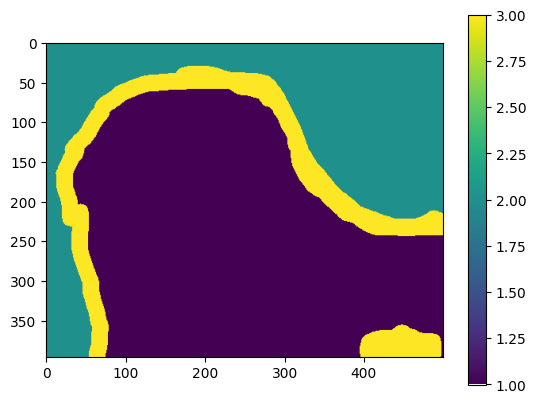

In [29]:
i = 4

image, (mask, cat) = dataset[idx_train[i]]

plt.imshow(mask)
plt.colorbar()

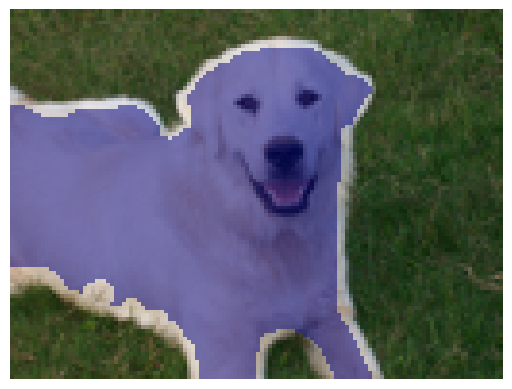

In [41]:
i = 1

image, (mask, cat) = dataset[idx_train[i]]
image, feature_map, mask = preprocess(image, mask)

plot_mask(image, mask)

In [8]:
features = []
labels = []

for i in tqdm(idx_train):
    image, (mask, cat) = dataset[i]
    image, feature_map, mask = preprocess(image, mask)
    fg = feature_map[mask]
    features.append(fg)
    labels.append(np.ones(len(fg)))
    bg = feature_map[~mask]
    features.append(bg)
    labels.append(np.zeros(len(bg)))

features = np.concatenate(features)
labels = np.concatenate(labels)

idx_0 = np.where(labels == 0)[0]
idx_1 = np.where(labels == 1)[0]

n = min(len(idx_0), len(idx_1))

idx_0_balanced = np.random.choice(idx_0, size=n, replace=False)
idx_1_balanced = np.random.choice(idx_1, size=n, replace=False)

balanced_idx = np.concatenate([idx_0_balanced, idx_1_balanced])
np.random.shuffle(balanced_idx)

features = features[balanced_idx]
labels = labels[balanced_idx]


  0%|          | 0/100 [00:00<?, ?it/s]

In [9]:
class ColorsDensity(BaseEstimator, ClassifierMixin):
    def __init__(self, reg=1e-6):
        self.reg = reg
        
        self.models = [None, None]

    def fit(self, X, y):
        """
        X: (n_samples, 3)
        y: (n_samples,) binary labels
        """
        _, n_features = X.shape

        for c in range(2):
            X_c = X[y == c]

            mean = X_c.mean(axis=0)
            cov = np.cov(X_c, rowvar=False)
            cov += self.reg * np.eye(n_features)
            self.models[c] = multivariate_normal(mean=mean, cov=cov)

        return self

    def predict_proba(self, X):
        """
        Returns: (n_samples, n_classes)
        """
        probs = []
        
        for model in self.models:
            probs.append(model.pdf(X))

        probs = np.stack(probs)
        probs = probs / np.sum(probs, axis=0)
        
        return probs.T

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.5, random_state=42, stratify=labels
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
model = LogisticRegression(max_iter=100, solver="newton-cholesky" )
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
model = ColorsDensity()
model.fit(X_train, y_train)

,reg,1e-06


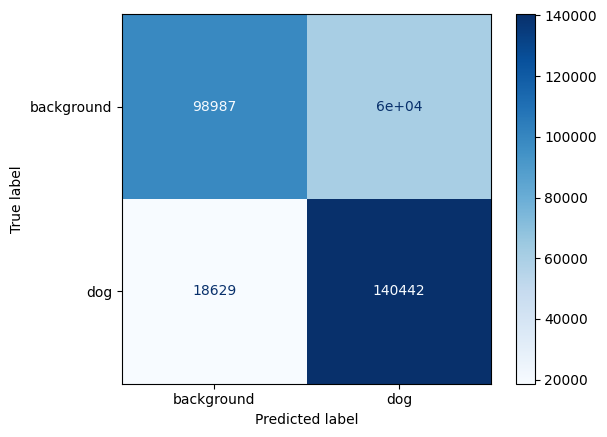

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["background", "dog"])
disp.plot(cmap="Blues")


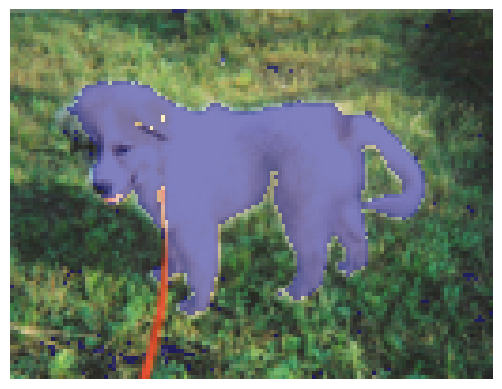

In [22]:
i = 5

image, (mask, cat) = test_dataset[idx_test[i]]
image, feature_map, mask = preprocess(image, mask)

H, W, C = feature_map.shape
X_flat = feature_map.reshape(-1, C)
if scaler is not None:
    X_flat = scaler.transform(X_flat)

probas = model.predict_proba(X_flat).reshape(H, W, -1)
pred = probas.argmax(axis=2)

plot_mask(image, pred)

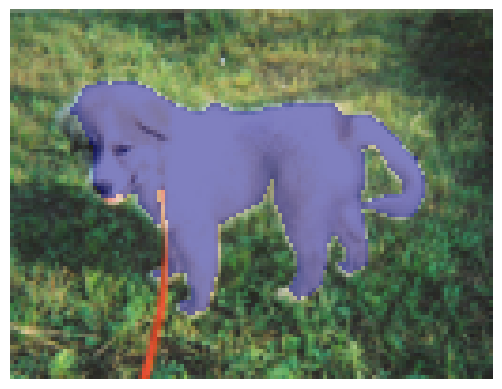

0.7672764227642277


In [23]:
i = 5
max_iter = 50
beta = 1
sigma = 100

image, (mask, cat) = test_dataset[idx_test[i]]
image, feature_map, mask = preprocess(image, mask)

graph = utils.segmentation_graph_from_image(model, feature_map, beta, sigma, scaler=scaler)
marginals = inference.loopy_bp(graph, max_iter)
m = utils.image_from_marginals(image, marginals)

plot_mask(image, m)
print(IoU(mask, m))

In [18]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import numpy as np

def run_single_image(k, model, beta, sigma, max_iter):
    image, (mask, cat) = test_dataset[k]
    image, features, mask = preprocess(image, mask)
    graph = utils.segmentation_graph_from_image(model, features, beta, sigma, scaler=scaler)
    marginals = inference.loopy_bp(graph, max_iter)
    m = utils.image_from_marginals(image, marginals)
    return IoU(mask, m)

def parallel_segmentation(idx, model, beta=1.0, sigma=100, max_iter=10, n_jobs=None):
    results = []
    with ProcessPoolExecutor(max_workers=n_jobs) as ex:
        futures = [ex.submit(run_single_image, k, model, beta, sigma, max_iter) for k in idx]
        for fut in tqdm(as_completed(futures), total=len(idx)):
            results.append(fut.result())
    return np.array(results)

def sequential_segmentation(idx, model, beta=1.0, sigma=100, max_iter=10):
    results = []
    for k in tqdm(idx):
        iou = run_single_image(k, model, beta, sigma, max_iter)
        results.append(iou)
    return np.array(results)

In [19]:
ious = parallel_segmentation(idx_test, model, beta, sigma, max_iter, n_jobs=16)
print("Mean IoU:", ious.mean())

100%|██████████| 100/100 [02:17<00:00,  1.37s/it]

Mean IoU: 0.4898271018145411


In [ ]:
ious = sequential_segmentation(idx_test, model, beta, sigma, max_iter)
print("Mean IoU:", ious.mean())

100%|██████████| 100/100 [06:37<00:00,  3.97s/it]

Mean IoU: 0.48981543660255267
